In [1]:
import random
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from IPython.display import clear_output
from pettingzoo import AECEnv
from pettingzoo.utils.agent_selector import agent_selector
from gymnasium import spaces

In [2]:
class GridForestEnv(AECEnv):
    metadata = {"name": "grid_forest_v0"}

    def __init__(self, size=5, n_trees=5, max_cycles=100):
        super().__init__()

        self.size = size
        self.n_trees = n_trees
        self.max_cycles = max_cycles

        self.possible_agents = ["cutter_0", "collector_0"]
        self.agents = self.possible_agents[:]

        # Actions:
        # 0 stay, 1 up, 2 down, 3 left, 4 right, 5 interact
        self._action_spaces = {
            agent: spaces.Discrete(6) for agent in self.agents
        }

        # Observation:
        # [self_x, self_y, nearest_tree_dx, nearest_tree_dy, total_fruit]
        self._observation_spaces = {
            agent: spaces.Box(low=-size, high=size, shape=(5,), dtype=np.float32)
            for agent in self.agents
        }

    def observation_space(self, agent):
        return self._observation_spaces[agent]

    def action_space(self, agent):
        return self._action_spaces[agent]

    def reset(self, seed=None, options=None):
        self.agents = self.possible_agents[:]
    
        self.rewards = {a: 0 for a in self.agents}
        self._cumulative_rewards = {a: 0 for a in self.agents} 
    
        self.terminations = {a: False for a in self.agents}
        self.truncations = {a: False for a in self.agents}
        self.infos = {a: {} for a in self.agents}

        self.cycle = 0

        # Agent positions
        self.positions = {
            agent: np.array([random.randint(0, self.size - 1),
                             random.randint(0, self.size - 1)])
            for agent in self.agents
        }

        # Trees: dict of position -> fruit count
        self.trees = {}
        for _ in range(self.n_trees):
            pos = (random.randint(0, self.size - 1),
                   random.randint(0, self.size - 1))
            self.trees[pos] = 3  # start with some fruit

        self._agent_selector = agent_selector(self.agents)
        self.agent_selection = self._agent_selector.next()

    def observe(self, agent):
        pos = self.positions[agent]

        # Find nearest tree
        if len(self.trees) > 0:
            nearest = min(self.trees.keys(),
                          key=lambda t: abs(t[0] - pos[0]) + abs(t[1] - pos[1]))
            dx = nearest[0] - pos[0]
            dy = nearest[1] - pos[1]
        else:
            dx, dy = 0, 0

        total_fruit = sum(self.trees.values())

        return np.array([pos[0], pos[1], dx, dy, total_fruit], dtype=np.float32)

    def _move(self, agent, action):
        x, y = self.positions[agent]

        if action == 1:   # up
            x = max(0, x - 1)
        elif action == 2: # down
            x = min(self.size - 1, x + 1)
        elif action == 3: # left
            y = max(0, y - 1)
        elif action == 4: # right
            y = min(self.size - 1, y + 1)

        self.positions[agent] = np.array([x, y])

    def _adjacent_tree(self, agent):
        x, y = self.positions[agent]
        for (tx, ty) in self.trees.keys():
            if abs(tx - x) + abs(ty - y) == 1:
                return (tx, ty)
        return None

    def step(self, action):
        agent = self.agent_selection

        if self.terminations[agent] or self.truncations[agent]:
            self.agent_selection = self._agent_selector.next()
            return

        self.rewards = {a: 0 for a in self.agents}        

        if action in [1, 2, 3, 4]:
            self._move(agent, action)

        elif action == 5:
            tree_pos = self._adjacent_tree(agent)

            if tree_pos is not None:
                if "collector" in agent:
                    if self.trees[tree_pos] > 0:
                        self.trees[tree_pos] -= 1
                        self.rewards[agent] += 1

                elif "cutter" in agent:
                    del self.trees[tree_pos]

        # Environment update after all agents acted
        if self._agent_selector.is_last():
            # Fruit regrowth
            for t in list(self.trees.keys()):
                if random.random() < 0.4:
                    self.trees[t] += 1

            # Random new tree (slow regeneration)
            if len(self.trees) < self.n_trees and random.random() < 0.1:
                pos = (random.randint(0, self.size - 1),
                       random.randint(0, self.size - 1))
                self.trees[pos] = 1

            # Starvation penalty
            if sum(self.trees.values()) == 0:
                for a in self.agents:
                    self.rewards[a] -= 1

            self.cycle += 1
            if self.cycle >= self.max_cycles:
                self.truncations = {a: True for a in self.agents}

        for a in self.agents:
            self._cumulative_rewards[a] += self.rewards[a]

        self.agent_selection = self._agent_selector.next()

    def render(self, config=None):
        # ---- DEFAULT CONFIG ----
        default_config = {
            "colors": {
                "empty": "#1e1e1e",
                "tree_low": "#2e7d32",
                "tree_high": "#66bb6a",
                "collector": "#42a5f5",
                "cutter": "#ef5350",
            },
            "show_text": True,
            "show_grid": True,
        }
    
        if config is None:
            config = default_config
        else:
            # merge user config
            for k in default_config:
                if k not in config:
                    config[k] = default_config[k]
    
        # ---- GRID ENCODING ----
        # 0 empty
        # 1 tree low fruit
        # 2 tree high fruit
        # 3 collector
        # 4 cutter
        grid = np.zeros((self.size, self.size))
    
        for (x, y), fruit in self.trees.items():
            if fruit <= 2:
                grid[x][y] = 1
            else:
                grid[x][y] = 2
    
        for agent, pos in self.positions.items():
            x, y = pos
            if "collector" in agent:
                grid[x][y] = 3
            else:
                grid[x][y] = 4
    
        # ---- COLORMAP ----
        cmap = ListedColormap([
            config["colors"]["empty"],
            config["colors"]["tree_low"],
            config["colors"]["tree_high"],
            config["colors"]["collector"],
            config["colors"]["cutter"],
        ])
    
        # ---- PLOT ----
        plt.figure(figsize=(5, 5))
        ax = plt.gca()
    
        im = ax.imshow(grid, cmap=cmap, vmin=0, vmax=4)
    
        # Fix grid alignment (cells look like squares, not floating)
        ax.set_xticks(np.arange(-0.5, self.size, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, self.size, 1), minor=True)
    
        if config["show_grid"]:
            ax.grid(which="minor", color="white", linestyle='-', linewidth=1)
    
        ax.tick_params(which="both", bottom=False, left=False,
                       labelbottom=False, labelleft=False)
    
        # ---- TEXT OVERLAY ----
        if config["show_text"]:
            for (x, y), fruit in self.trees.items():
                ax.text(y, x, str(fruit),
                        ha='center', va='center',
                        color='white', fontsize=10)
    
            # Example: agent "satiety" placeholder
            if hasattr(self, "satiety"):
                for agent, pos in self.positions.items():
                    x, y = pos
                    val = self.satiety.get(agent, 0)
                    ax.text(y, x, f"{val}",
                            ha='center', va='center',
                            color='black', fontsize=8)
    
        # ---- GLOBAL METRICS ----
        total_fruit = sum(self.trees.values())
        num_trees = len(self.trees)
    
        ax.set_title(f"Trees: {num_trees} | Total Fruit: {total_fruit}")
    
        plt.tight_layout()
        plt.show()
        clear_output(wait=True)

In [3]:
%matplotlib inline

KeyboardInterrupt: 

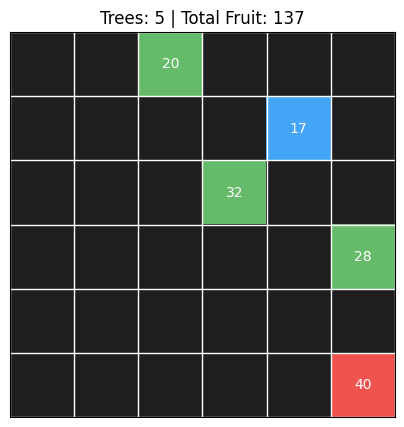

In [4]:
env = GridForestEnv(size=6)
env.reset()

for agent in env.agent_iter():
    obs = env.observe(agent)
    action = env.action_space(agent).sample()
    env.step(action)

    if env._agent_selector.is_last():
        env.render()
        time.sleep(0.2)